# **Team Name:** `B Team`
# **Authors:** `Madelyne Dusbabek, Gregory Lowman, Jay Hall`
# **Cell Number:** `R22`
# **J-V Apparatus Number:** `JV 3`
# **EQE Apparatus Number:** `EQE 2`

### This week you will do the following data analysis:

**Note:** Because you were not in lab last week, your TAs collected J-V and EQE data on your cells. You will find this data in your group's Google Drive. You will need to process **both** this week's data and last week's TA-collected data.

1.   Plot the J-V curves of your forward scans for all pixels (this week's data and last week's TA data)
2.   Process J-V data for both this week and the break week (calculate $J_{sc}$, PCE, $V_{pmax}$, $J_{pmax}$)
3.   Follow the uncertainty workflow from Data Collection 2 for both new datasets (power vs. voltage plots, estimate uncertainties, propagate errors)
4.   Update your multi-week PCE vs. time plot to include all five time points with error bars
5.   Create EQE CSV files for both this week and the break week
6.   Update your multi-week EQE subplot figures to include all five weeks of data

### **You have done all of these analyses in previous Colab notebooks. Please copy, edit, and reuse your code from previous weeks.**


## **J-V Analysis**

1. Create a SINGLE plot of the J-V curves of the **forward scans** with data from all pixels for this week's data. Then create a separate plot for last week's TA data.

    a. Remember you can copy and paste code from previous notebooks and use AI tools.

    b. Also remember that you measured I-V from the pixels, so you will need to determine the current density, J, first before plotting.

# **Week 6 JV Curve from forward scans**

Mounted at /content/drive
[ok] Loaded 8 JV files


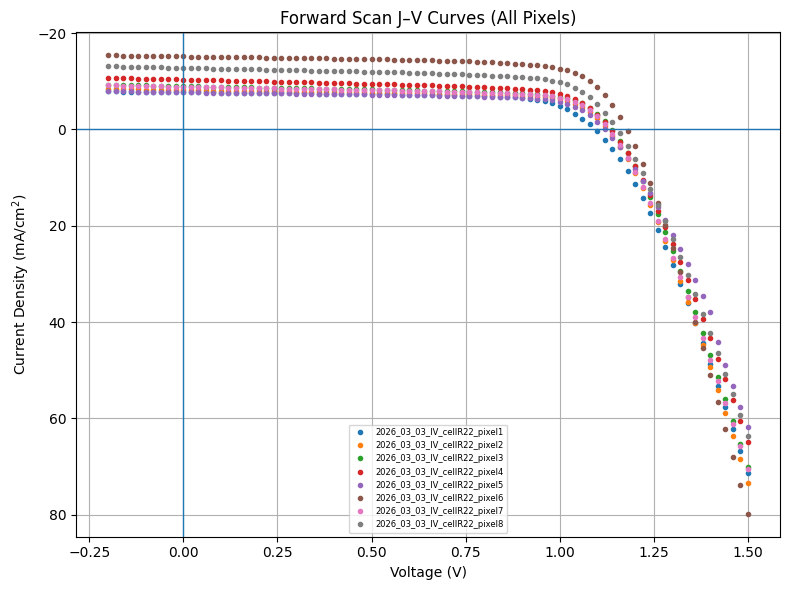

In [1]:
# @title
# Week 6
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

AREA = 0.14  # cm^2

folder = "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week6/JV_Data"

if not os.path.exists(folder):
    raise FileNotFoundError(f"Folder not found:\n{folder}")

files = sorted(
    f for f in os.listdir(folder)
    if f.endswith(".csv") and "_IV_cell" in f and "_pixel" in f
)

if not files:
    raise SystemExit("No JV files found in folder.")

jv_data = {}

for f in files:
    full_path = os.path.join(folder, f)
    df = pd.read_csv(full_path)

    df.columns = df.columns.str.strip()

    # Verify required columns exist
    required_cols = ["Voltage (V)", "Forward_mean (mA)"]
    if not all(col in df.columns for col in required_cols):
        print(f"[skip] Unexpected format: {f}")
        continue

    name = f.replace(".csv", "")

    jv_data[name] = pd.DataFrame({
        "Voltage (V)": pd.to_numeric(df["Voltage (V)"], errors="coerce"),
        "Current Density (mA/cm^2)":
            pd.to_numeric(df["Forward_mean (mA)"], errors="coerce") / AREA
    })

print(f"[ok] Loaded {len(jv_data)} JV files")

plt.figure(figsize=(8,6))

for name, jv in jv_data.items():
    plt.plot(
        jv["Voltage (V)"],
        jv["Current Density (mA/cm^2)"],
        ".",
        label=name
    )

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("Voltage (V)")
plt.ylabel("Current Density (mA/cm$^2$)")
plt.title("Forward Scan J–V Curves (All Pixels)")
plt.legend(fontsize=6)
plt.grid(True)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# **Week 5 JV Curve from forward scans**

Mounted at /content/drive
[ok] Loaded 8 JV files


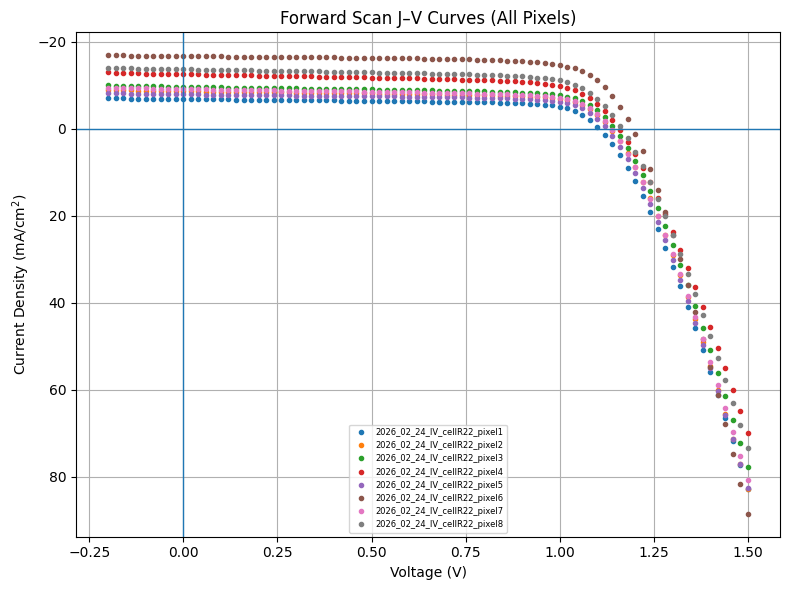

In [ ]:
# @title
# Week 5
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

AREA = 0.14  # cm^2

folder = "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week5/JV_Data"

if not os.path.exists(folder):
    raise FileNotFoundError(f"Folder not found:\n{folder}")

files = sorted(
    f for f in os.listdir(folder)
    if f.endswith(".csv") and "_IV_cell" in f and "_pixel" in f
)

if not files:
    raise SystemExit("No JV files found in folder.")

jv_data = {}

for f in files:
    full_path = os.path.join(folder, f)
    df = pd.read_csv(full_path)

    df.columns = df.columns.str.strip()

    # Verify required columns exist
    required_cols = ["Voltage (V)", "Forward_mean (mA)"]
    if not all(col in df.columns for col in required_cols):
        print(f"[skip] Unexpected format: {f}")
        continue

    name = f.replace(".csv", "")

    jv_data[name] = pd.DataFrame({
        "Voltage (V)": pd.to_numeric(df["Voltage (V)"], errors="coerce"),
        "Current Density (mA/cm^2)":
            pd.to_numeric(df["Forward_mean (mA)"], errors="coerce") / AREA
    })

print(f"[ok] Loaded {len(jv_data)} JV files")

plt.figure(figsize=(8,6))

for name, jv in jv_data.items():
    plt.plot(
        jv["Voltage (V)"],
        jv["Current Density (mA/cm^2)"],
        ".",
        label=name
    )

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("Voltage (V)")
plt.ylabel("Current Density (mA/cm$^2$)")
plt.title("Forward Scan J–V Curves (All Pixels)")
plt.legend(fontsize=6)
plt.grid(True)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

**Question 1:** Discuss what you observe from looking at the comparison of your J-V curves. Do you have any pixels showing different behaviors?

All of our pixels are relativly the same. The only consitent difference we have observed is that pixel 6 has steadily been more powerful than the rest. But it shows the same trend as the voltage increases, it just has a slightly higher current density.



2. Calculate the $J_{sc}$ and PCE values for each pixel for both this week and

the break week. You will need to do this for **both** new datasets.

3. Follow the uncertainty workflow from Data Collection 2 for both new datasets: create power vs. voltage plots, estimate $dV_{pmax}$ and $dJ_{pmax}$, create uncertainty input CSVs, and propagate uncertainties to get PCE error bars.

4. Update the PCE vs. time plot you made for the Data Collection 2 week to include both new weeks of data with error bars. This figure should now have **five** time points: baseline data, Data Collection 1, Data Collection 2, break week (TA data), and Data Collection 3.

    Remember to calculate the time values (hours since stressing began) for each week's data, including the break week.

# **Week 6 Jsc and PCE**

In [ ]:
# @title
# Your PCE calculation, uncertainty propagation, and PCE vs. time plotting code here

# Variables needed for J-V analysis
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Update variables as needed
date_str = "2026_03_03"
cell_id  = "R22"
area_cm2 = 0.14
P_in = 99.8
pixels = range(1, 9)

folder = "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week6/JV_Data"

# Column names matching the CSV output from measurement software
# JV data columns: Voltage (V), Forward_mean (mA), Forward_std (mA), Forward_n,
#                   Reverse_mean (mA), Reverse_std (mA), Reverse_n
COL_V          = "Voltage (V)"
COL_Forward_mA = "Forward_mean (mA)"
COL_Fwd_std    = "Forward_std (mA)"
COL_Fwd_n      = "Forward_n"

# Store raw DataFrames and JV DataFrames for each pixel
raw_data = {}
jv_data  = {}

# Load each pixel's data
for n in pixels:
    fname = f"{date_str}_IV_cell{cell_id}_pixel{n}.csv"
    try:
        df_raw = pd.read_csv(os.path.join(folder, fname))
        raw_data[n] = df_raw  # keep the full raw data for SE calculations

        df_jv = pd.DataFrame({
            "Voltage (V)": df_raw[COL_V].astype(float),
            "Current Density (mA/cm^2)": df_raw[COL_Forward_mA].astype(float) / area_cm2
        }).sort_values("Voltage (V)").reset_index(drop=True)

        # Add power density
        df_jv["Power Density (mW/cm^2)"] = (
            df_jv["Voltage (V)"] * df_jv["Current Density (mA/cm^2)"]
        )

        jv_data[n] = df_jv
        print(f"[ok] Loaded pixel {n}")

    except FileNotFoundError:
        print(f"[skip] Pixel {n}: file not found ({fname})")
    except Exception as e:
        print(f"[skip] Pixel {n}: error reading {fname}: {e}")

# --- Calculate PCE parameters and SE-based uncertainties ---
rows = []
valid_pixels = sorted(jv_data.keys())

for n in valid_pixels:
    jv  = jv_data[n]
    raw = raw_data[n].sort_values(COL_V).reset_index(drop=True)

    V = jv["Voltage (V)"].to_numpy()
    J = jv["Current Density (mA/cm^2)"].to_numpy()

    # --- Standard PV parameters ---
    Voc = float(np.interp(0.0, J, V))
    Jsc = float(np.interp(0.0, V, J))
    P   = V * J
    idx_pmax = int(np.argmin(P))   # most negative power = MPP
    Vmp = float(V[idx_pmax])
    Jmp = float(J[idx_pmax])

    denom = abs(Jsc) * Voc
    FF  = (Vmp * abs(Jmp)) / denom if denom != 0 else np.nan
    PCE = ((Voc * abs(Jsc) * FF) / P_in) * 100 if P_in != 0 else np.nan

    # --- Standard Error at the MPP ---
    std_mA_mpp = float(raw[COL_Fwd_std].iloc[idx_pmax])
    n_mpp      = float(raw[COL_Fwd_n].iloc[idx_pmax])

    if n_mpp > 1:
        SE_I_mpp = std_mA_mpp / np.sqrt(n_mpp)    # SE of current in mA
        SE_J_mpp = SE_I_mpp / area_cm2             # SE of current density in mA/cm^2
    else:
        SE_J_mpp = np.nan
        print(f"  [warn] Pixel {n}: n=1 at MPP, SE undefined")

    # --- Standard Error at V=0 (for Jsc uncertainty) ---
    idx_v0 = int(np.argmin(np.abs(raw[COL_V].to_numpy())))
    std_mA_v0 = float(raw[COL_Fwd_std].iloc[idx_v0])
    n_v0      = float(raw[COL_Fwd_n].iloc[idx_v0])

    if n_v0 > 1:
        SE_Jsc = (std_mA_v0 / np.sqrt(n_v0)) / area_cm2
    else:
        SE_Jsc = np.nan

    # --- Voltage uncertainty: half the voltage step size ---
    if len(V) > 1:
        voltage_step = float(np.median(np.abs(np.diff(V))))
        dV = voltage_step / 2.0
    else:
        dV = np.nan

    rows.append({
        "Pixel Number":        n,
        "Jsc (mA/cm^2)":      Jsc,
        "SE_Jsc (mA/cm^2)":   SE_Jsc,
        "J_pmax (mA/cm^2)":   Jmp,
        "V_pmax (V)":         Vmp,
        "PCE":                PCE,
        "SE_Jpmax (mA/cm^2)": SE_J_mpp,
        "dV (V)":             dV,
        "n_at_MPP":           n_mpp,
    })

# Convert to DataFrame and write out as CSV
out_name = "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week6/2026_03_03_jsc_pce_cellR22.csv"
df_out = pd.DataFrame(rows)
df_out.sort_values("Pixel Number").to_csv(out_name, index=False)

if df_out.empty:
    print("[warn] No valid pixels found — did you run the loader above?")
else:
    df_out.sort_values("Pixel Number").to_csv(out_name, index=False)
    print(f"\n[ok] Wrote {out_name}")
    display(df_out)

[ok] Loaded pixel 1
[ok] Loaded pixel 2
[ok] Loaded pixel 3
[ok] Loaded pixel 4
[ok] Loaded pixel 5
[ok] Loaded pixel 6
[ok] Loaded pixel 7
[ok] Loaded pixel 8

[ok] Wrote /content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week6/2026_03_03_jsc_pce_cellR22.csv


,Pixel Number,Jsc (mA/cm^2),SE_Jsc (mA/cm^2),J_pmax (mA/cm^2),V_pmax (V),PCE,SE_Jpmax (mA/cm^2),dV (V),n_at_MPP
0,1,-7.735500,0.003343,-6.539429,0.90,5.897280,0.003720,0.01,10.0
1,2,-8.159286,0.004721,-6.686214,0.96,6.431629,0.005773,0.01,10.0
2,3,-8.982500,0.004719,-7.174357,0.96,6.901185,0.005559,0.01,10.0
3,4,-10.349786,0.006047,-7.921143,0.96,7.619536,0.007090,0.01,10.0
4,5,-7.732000,0.003526,-6.378643,0.94,6.007940,0.005803,0.01,10.0
5,6,-15.151000,0.003969,-12.919071,0.98,12.686062,0.005568,0.01,10.0
6,7,-8.830214,0.005640,-7.045071,0.96,6.776822,0.003494,0.01,10.0
7,8,-12.766857,0.004895,-10.394143,0.96,9.998374,0.005706,0.01,10.0


# **Week 5 Jsc and PCE**

In [ ]:
# @title
# Your PCE calculation, uncertainty propagation, and PCE vs. time plotting code here

# Variables needed for J-V analysis
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Update variables as needed
date_str = "2026_02_24"
cell_id  = "R22"
area_cm2 = 0.14
P_in = 99.8
pixels = range(1, 9)

folder = "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week5/JV_Data"

# Column names matching the CSV output from measurement software
# JV data columns: Voltage (V), Forward_mean (mA), Forward_std (mA), Forward_n,
#                   Reverse_mean (mA), Reverse_std (mA), Reverse_n
COL_V          = "Voltage (V)"
COL_Forward_mA = "Forward_mean (mA)"
COL_Fwd_std    = "Forward_std (mA)"
COL_Fwd_n      = "Forward_n"

# Store raw DataFrames and JV DataFrames for each pixel
raw_data = {}
jv_data  = {}

# Load each pixel's data
for n in pixels:
    fname = f"{date_str}_IV_cell{cell_id}_pixel{n}.csv"
    try:
        df_raw = pd.read_csv(os.path.join(folder, fname))
        raw_data[n] = df_raw  # keep the full raw data for SE calculations

        df_jv = pd.DataFrame({
            "Voltage (V)": df_raw[COL_V].astype(float),
            "Current Density (mA/cm^2)": df_raw[COL_Forward_mA].astype(float) / area_cm2
        }).sort_values("Voltage (V)").reset_index(drop=True)

        # Add power density
        df_jv["Power Density (mW/cm^2)"] = (
            df_jv["Voltage (V)"] * df_jv["Current Density (mA/cm^2)"]
        )

        jv_data[n] = df_jv
        print(f"[ok] Loaded pixel {n}")

    except FileNotFoundError:
        print(f"[skip] Pixel {n}: file not found ({fname})")
    except Exception as e:
        print(f"[skip] Pixel {n}: error reading {fname}: {e}")

# --- Calculate PCE parameters and SE-based uncertainties ---
rows = []
valid_pixels = sorted(jv_data.keys())

for n in valid_pixels:
    jv  = jv_data[n]
    raw = raw_data[n].sort_values(COL_V).reset_index(drop=True)

    V = jv["Voltage (V)"].to_numpy()
    J = jv["Current Density (mA/cm^2)"].to_numpy()

    # --- Standard PV parameters ---
    Voc = float(np.interp(0.0, J, V))
    Jsc = float(np.interp(0.0, V, J))
    P   = V * J
    idx_pmax = int(np.argmin(P))   # most negative power = MPP
    Vmp = float(V[idx_pmax])
    Jmp = float(J[idx_pmax])

    denom = abs(Jsc) * Voc
    FF  = (Vmp * abs(Jmp)) / denom if denom != 0 else np.nan
    PCE = ((Voc * abs(Jsc) * FF) / P_in) * 100 if P_in != 0 else np.nan

    # --- Standard Error at the MPP ---
    std_mA_mpp = float(raw[COL_Fwd_std].iloc[idx_pmax])
    n_mpp      = float(raw[COL_Fwd_n].iloc[idx_pmax])

    if n_mpp > 1:
        SE_I_mpp = std_mA_mpp / np.sqrt(n_mpp)    # SE of current in mA
        SE_J_mpp = SE_I_mpp / area_cm2             # SE of current density in mA/cm^2
    else:
        SE_J_mpp = np.nan
        print(f"  [warn] Pixel {n}: n=1 at MPP, SE undefined")

    # --- Standard Error at V=0 (for Jsc uncertainty) ---
    idx_v0 = int(np.argmin(np.abs(raw[COL_V].to_numpy())))
    std_mA_v0 = float(raw[COL_Fwd_std].iloc[idx_v0])
    n_v0      = float(raw[COL_Fwd_n].iloc[idx_v0])

    if n_v0 > 1:
        SE_Jsc = (std_mA_v0 / np.sqrt(n_v0)) / area_cm2
    else:
        SE_Jsc = np.nan

    # --- Voltage uncertainty: half the voltage step size ---
    if len(V) > 1:
        voltage_step = float(np.median(np.abs(np.diff(V))))
        dV = voltage_step / 2.0
    else:
        dV = np.nan

    rows.append({
        "Pixel Number":        n,
        "Jsc (mA/cm^2)":      Jsc,
        "SE_Jsc (mA/cm^2)":   SE_Jsc,
        "J_pmax (mA/cm^2)":   Jmp,
        "V_pmax (V)":         Vmp,
        "PCE":                PCE,
        "SE_Jpmax (mA/cm^2)": SE_J_mpp,
        "dV (V)":             dV,
        "n_at_MPP":           n_mpp,
    })

# Convert to DataFrame and write out as CSV
out_name = "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week5/2026_02_24_jsc_pce_cellR22.csv"
df_out = pd.DataFrame(rows)
df_out.sort_values("Pixel Number").to_csv(out_name, index=False)

if df_out.empty:
    print("[warn] No valid pixels found — did you run the loader above?")
else:
    df_out.sort_values("Pixel Number").to_csv(out_name, index=False)
    print(f"\n[ok] Wrote {out_name}")
    display(df_out)

[ok] Loaded pixel 1
[ok] Loaded pixel 2
[ok] Loaded pixel 3
[ok] Loaded pixel 4
[ok] Loaded pixel 5
[ok] Loaded pixel 6
[ok] Loaded pixel 7
[ok] Loaded pixel 8

[ok] Wrote /content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week5/2026_02_24_jsc_pce_cellR22.csv


,Pixel Number,Jsc (mA/cm^2),SE_Jsc (mA/cm^2),J_pmax (mA/cm^2),V_pmax (V),PCE,SE_Jpmax (mA/cm^2),dV (V),n_at_MPP
0,1,-6.823286,0.003587,-5.673500,0.94,5.343778,0.004813,0.01,10.0
1,2,-8.639929,0.003284,-7.064571,0.98,6.937154,0.004531,0.01,10.0
2,3,-9.637857,0.003829,-7.883714,0.98,7.741523,0.003944,0.01,10.0
3,4,-12.547286,0.003262,-10.379571,0.96,9.984357,0.006148,0.01,10.0
4,5,-7.919643,0.002830,-6.625000,0.96,6.372745,0.004531,0.01,10.0
5,6,-16.699429,0.004407,-14.644571,1.00,14.673919,0.004533,0.01,10.0
6,7,-9.111929,0.003347,-7.520571,0.96,7.234217,0.004145,0.01,10.0
7,8,-13.651643,0.003000,-11.391500,0.98,11.186042,0.003869,0.01,10.0


**Question 2:** Discuss what you observe from looking at the PCE over time. Has anything changed over the past few weeks?

Our PCE percentage is slowly decreasing as the weeks progress. Our initial week one was much lower than the rest for some reason, which we can look into; however, since week three there has been a steady decrease in the percentage that we can anticipate to continue.



# **Week 6 Jsc Pce Uncertainty**

Writes file to directory, need to download and move

In [ ]:
# @title
import pandas as pd
import os
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
import numpy as np
# --- PCE Uncertainty Propagation using Standard Error ---
folder = "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week7"
date_str = "2026_03_10"
cell_id  = "R22"
P_in = 99.8

df = pd.read_csv(os.path.join(folder, f"{date_str}_jsc_pce_cell{cell_id}.csv"))

# Time variable — update depending on the week
t = 1008  # hours since initial measurement (update each week)
df["Time (hr)"] = t

# Uncertainty in light power (from solar simulator calibration)
dP_in = 0.9  # mW/cm^2

# --- Propagate uncertainty for PCE ---
J_abs   = np.abs(df["J_pmax (mA/cm^2)"].to_numpy())
V_vals  = np.abs(df["V_pmax (V)"].to_numpy())
PCE_vals = df["PCE"].to_numpy()
dJ      = df["SE_Jpmax (mA/cm^2)"].to_numpy()
dV      = df["dV (V)"].to_numpy()

# Relative uncertainties
rel_J   = dJ / J_abs
rel_V   = dV / V_vals
rel_Pin = dP_in / P_in

# PCE uncertainty (in percentage points, same units as PCE)
df["PCE_uncertainty (%)"] = PCE_vals * np.sqrt(rel_J**2 + rel_V**2 + rel_Pin**2)

# Jsc uncertainty for reporting
df["Jsc_uncertainty (mA/cm^2)"] = df["SE_Jsc (mA/cm^2)"]

# Write final output
out_name = f"{date_str}_jsc_pce_uncertainties_cell{cell_id}.csv"
cols_to_write = [
    "Pixel Number", "Time (hr)",
    "Jsc (mA/cm^2)", "Jsc_uncertainty (mA/cm^2)",
    "PCE", "PCE_uncertainty (%)"
]
df[cols_to_write].to_csv(out_name, index=False)
print(f"[ok] Wrote {out_name}")
display(df[cols_to_write])

# Print a summary for quick review
print("\n--- Summary ---")
for _, row in df.iterrows():
    pix = int(row["Pixel Number"])
    pce = row["PCE"]
    dpce = row["PCE_uncertainty (%)"]
    jsc = row["Jsc (mA/cm^2)"]
    djsc = row["Jsc_uncertainty (mA/cm^2)"]
    print(f"  Pixel {pix}: PCE = {pce:.2f} +/- {dpce:.2f} %,  "
          f"Jsc = {jsc:.3f} +/- {djsc:.3f} mA/cm^2")

# --- Relative uncertainty breakdown ---
print("\n--- Relative Uncertainty Breakdown (as %) ---")
print(f"  {'Pixel':>5s}  {'δJ/J':>8s}  {'δV/V':>8s}  {'δP/P':>8s}  {'Total':>8s}")
for _, row in df.iterrows():
    pix = int(row["Pixel Number"])
    rJ = row["SE_Jpmax (mA/cm^2)"] / abs(row["J_pmax (mA/cm^2)"]) * 100
    rV = row["dV (V)"] / abs(row["V_pmax (V)"]) * 100
    rP = dP_in / P_in * 100
    total = np.sqrt((rJ/100)**2 + (rV/100)**2 + (rP/100)**2) * 100
    print(f"  {pix:5d}  {rJ:7.3f}%  {rV:7.3f}%  {rP:7.3f}%  {total:7.3f}%")

print(f"\n  Note: δJ/J is the SE-based measurement uncertainty (statistical).")
print(f"        δV/V is the voltage step resolution (instrumental).")
print(f"        δP/P is the solar simulator calibration (systematic).")

Mounted at /content/drive
[ok] Wrote 2026_03_10_jsc_pce_uncertainties_cellR22.csv


,Pixel Number,Time (hr),Jsc (mA/cm^2),Jsc_uncertainty (mA/cm^2),PCE,PCE_uncertainty (%)
0,1,1008,-8.738786,0.003580,5.668175,0.088900
1,2,1008,-8.510143,0.005965,6.495365,0.090671
2,3,1008,-9.341143,0.005604,7.088146,0.098935
3,4,1008,-9.725929,0.005631,6.918437,0.097914
4,5,1008,-7.987357,0.004427,6.144782,0.085769
5,6,1008,-14.965214,0.002561,12.185857,0.167955
6,7,1008,-9.256643,0.004764,7.048587,0.098459
7,8,1008,-12.661714,0.004585,9.740760,0.135968



--- Summary ---
  Pixel 1: PCE = 5.67 +/- 0.09 %,  Jsc = -8.739 +/- 0.004 mA/cm^2
  Pixel 2: PCE = 6.50 +/- 0.09 %,  Jsc = -8.510 +/- 0.006 mA/cm^2
  Pixel 3: PCE = 7.09 +/- 0.10 %,  Jsc = -9.341 +/- 0.006 mA/cm^2
  Pixel 4: PCE = 6.92 +/- 0.10 %,  Jsc = -9.726 +/- 0.006 mA/cm^2
  Pixel 5: PCE = 6.14 +/- 0.09 %,  Jsc = -7.987 +/- 0.004 mA/cm^2
  Pixel 6: PCE = 12.19 +/- 0.17 %,  Jsc = -14.965 +/- 0.003 mA/cm^2
  Pixel 7: PCE = 7.05 +/- 0.10 %,  Jsc = -9.257 +/- 0.005 mA/cm^2
  Pixel 8: PCE = 9.74 +/- 0.14 %,  Jsc = -12.662 +/- 0.005 mA/cm^2

--- Relative Uncertainty Breakdown (as %) ---
  Pixel      δJ/J      δV/V      δP/P     Total
      1    0.055%    1.282%    0.902%    1.568%
      2    0.060%    1.064%    0.902%    1.396%
      3    0.057%    1.064%    0.902%    1.396%
      4    0.091%    1.087%    0.902%    1.415%
      5    0.057%    1.064%    0.902%    1.396%
      6    0.037%    1.042%    0.902%    1.378%
      7    0.079%    1.064%    0.902%    1.397%
      8    0.059%    

# **Week 5 Jsc PCE Uncertainty**

Writes file to directory, need to download and move

In [ ]:
# @title
# --- PCE Uncertainty Propagation using Standard Error ---
folder = "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week5"
date_str = "2026_02_24"
cell_id  = "R22"

df = pd.read_csv(os.path.join(folder, f"{date_str}_jsc_pce_cell{cell_id}.csv"))

# Time variable — update depending on the week
t = 840  # hours since initial measurement (update each week)
df["Time (hr)"] = t

# Uncertainty in light power (from solar simulator calibration)
dP_in = 0.9  # mW/cm^2

# --- Propagate uncertainty for PCE ---
J_abs   = np.abs(df["J_pmax (mA/cm^2)"].to_numpy())
V_vals  = np.abs(df["V_pmax (V)"].to_numpy())
PCE_vals = df["PCE"].to_numpy()
dJ      = df["SE_Jpmax (mA/cm^2)"].to_numpy()
dV      = df["dV (V)"].to_numpy()

# Relative uncertainties
rel_J   = dJ / J_abs
rel_V   = dV / V_vals
rel_Pin = dP_in / P_in

# PCE uncertainty (in percentage points, same units as PCE)
df["PCE_uncertainty (%)"] = PCE_vals * np.sqrt(rel_J**2 + rel_V**2 + rel_Pin**2)

# Jsc uncertainty for reporting
df["Jsc_uncertainty (mA/cm^2)"] = df["SE_Jsc (mA/cm^2)"]

# Write final output
out_name = f"{date_str}_jsc_pce_uncertainties_cell{cell_id}.csv"
cols_to_write = [
    "Pixel Number", "Time (hr)",
    "Jsc (mA/cm^2)", "Jsc_uncertainty (mA/cm^2)",
    "PCE", "PCE_uncertainty (%)"
]
df[cols_to_write].to_csv(out_name, index=False)
print(f"[ok] Wrote {out_name}")
display(df[cols_to_write])

# Print a summary for quick review
print("\n--- Summary ---")
for _, row in df.iterrows():
    pix = int(row["Pixel Number"])
    pce = row["PCE"]
    dpce = row["PCE_uncertainty (%)"]
    jsc = row["Jsc (mA/cm^2)"]
    djsc = row["Jsc_uncertainty (mA/cm^2)"]
    print(f"  Pixel {pix}: PCE = {pce:.2f} +/- {dpce:.2f} %,  "
          f"Jsc = {jsc:.3f} +/- {djsc:.3f} mA/cm^2")

# --- Relative uncertainty breakdown ---
print("\n--- Relative Uncertainty Breakdown (as %) ---")
print(f"  {'Pixel':>5s}  {'δJ/J':>8s}  {'δV/V':>8s}  {'δP/P':>8s}  {'Total':>8s}")
for _, row in df.iterrows():
    pix = int(row["Pixel Number"])
    rJ = row["SE_Jpmax (mA/cm^2)"] / abs(row["J_pmax (mA/cm^2)"]) * 100
    rV = row["dV (V)"] / abs(row["V_pmax (V)"]) * 100
    rP = dP_in / P_in * 100
    total = np.sqrt((rJ/100)**2 + (rV/100)**2 + (rP/100)**2) * 100
    print(f"  {pix:5d}  {rJ:7.3f}%  {rV:7.3f}%  {rP:7.3f}%  {total:7.3f}%")

print(f"\n  Note: δJ/J is the SE-based measurement uncertainty (statistical).")
print(f"        δV/V is the voltage step resolution (instrumental).")
print(f"        δP/P is the solar simulator calibration (systematic).")

[ok] Wrote 2026_02_24_jsc_pce_uncertainties_cellR22.csv


,Pixel Number,Time (hr),Jsc (mA/cm^2),Jsc_uncertainty (mA/cm^2),PCE,PCE_uncertainty (%)
0,1,840,-6.823286,0.003587,5.343778,0.074664
1,2,840,-8.639929,0.003284,6.937154,0.094574
2,3,840,-9.637857,0.003829,7.741523,0.105495
3,4,840,-12.547286,0.003262,9.984357,0.137691
4,5,840,-7.919643,0.002830,6.372745,0.087911
5,6,840,-16.699429,0.004407,14.673919,0.197647
6,7,840,-9.111929,0.003347,7.234217,0.099752
7,8,840,-13.651643,0.003000,11.186042,0.152378



--- Summary ---
  Pixel 1: PCE = 5.34 +/- 0.07 %,  Jsc = -6.823 +/- 0.004 mA/cm^2
  Pixel 2: PCE = 6.94 +/- 0.09 %,  Jsc = -8.640 +/- 0.003 mA/cm^2
  Pixel 3: PCE = 7.74 +/- 0.11 %,  Jsc = -9.638 +/- 0.004 mA/cm^2
  Pixel 4: PCE = 9.98 +/- 0.14 %,  Jsc = -12.547 +/- 0.003 mA/cm^2
  Pixel 5: PCE = 6.37 +/- 0.09 %,  Jsc = -7.920 +/- 0.003 mA/cm^2
  Pixel 6: PCE = 14.67 +/- 0.20 %,  Jsc = -16.699 +/- 0.004 mA/cm^2
  Pixel 7: PCE = 7.23 +/- 0.10 %,  Jsc = -9.112 +/- 0.003 mA/cm^2
  Pixel 8: PCE = 11.19 +/- 0.15 %,  Jsc = -13.652 +/- 0.003 mA/cm^2

--- Relative Uncertainty Breakdown (as %) ---
  Pixel      δJ/J      δV/V      δP/P     Total
      1    0.085%    1.064%    0.902%    1.397%
      2    0.064%    1.020%    0.902%    1.363%
      3    0.050%    1.020%    0.902%    1.363%
      4    0.059%    1.042%    0.902%    1.379%
      5    0.068%    1.042%    0.902%    1.379%
      6    0.031%    1.000%    0.902%    1.347%
      7    0.055%    1.042%    0.902%    1.379%
      8    0.034%  

# **PCE vs. Time Plot**

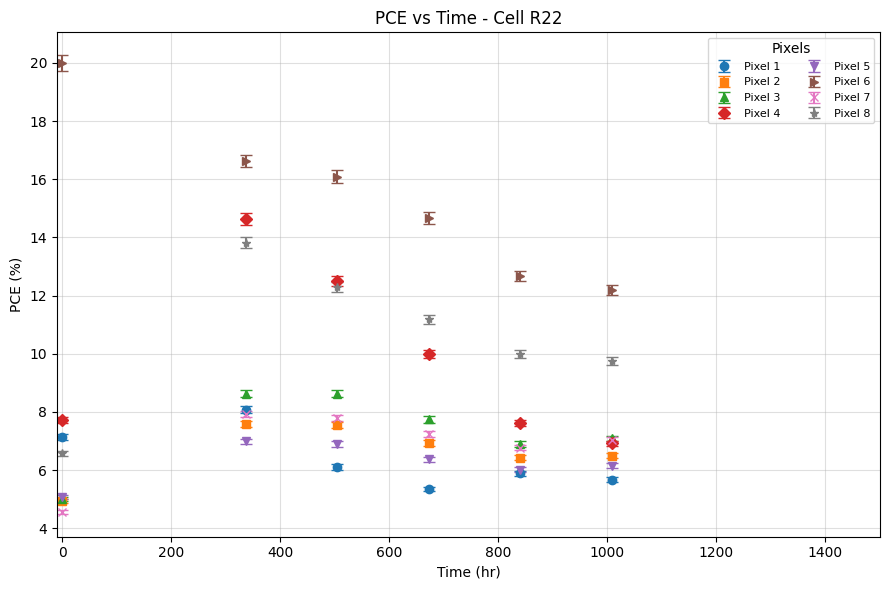

In [ ]:
# @title
### MUST UPLOAD ALL FILES INTO DIRECTORY ###

# Add CSV files you want to have on the plot
files = [
    "/content/2026_01_27_jsc_pce_uncertainties_cellR22.csv",
    "/content/2026_02_10_jsc_pce_uncertainties_cellR22.csv",
    "/content/2026_02_17_jsc_pce_uncertainties_cellR22.csv",
    "/content/2026_02_24_jsc_pce_uncertainties_cellR22.csv",
    "/content/2026_03_03_jsc_pce_uncertainties_cellR22.csv",
    "/content/2026_03_10_jsc_pce_uncertainties_cellR22.csv",
    # etc,
]

# Load and combine data, with the check to identify and skip any missng files missing files
dfs = []
for f in files:
    try:
        d = pd.read_csv(os.path.join(folder, f))
        d["source_file"] = f  # optional: helps debug
        dfs.append(d)
    except FileNotFoundError:
        print(f"[skip] missing file: {f}")

if not dfs:
    raise SystemExit("No data files loaded. Check file names above.")

all_df = pd.concat(dfs, ignore_index=True)

# Keep only the columns we need and make them be numbers. You can add additional details from the input files if you want.
need = ["Pixel Number", "Time (hr)", "PCE", "PCE_uncertainty (%)"]
missing = [c for c in need if c not in all_df.columns]
if missing:
    raise ValueError(f"Missing required columns in data: {missing}")

all_df["Pixel Number"] = pd.to_numeric(all_df["Pixel Number"], errors="coerce").astype("Int64")
all_df["Time (hr)"]    = pd.to_numeric(all_df["Time (hr)"], errors="coerce")
all_df["PCE"]          = pd.to_numeric(all_df["PCE"], errors="coerce")
all_df["PCE_uncertainty (%)"] = pd.to_numeric(all_df["PCE_uncertainty (%)"], errors="coerce")

# Drop rows missing basics and dedupe (keep last if duplicates exist)
all_df = (
    all_df.dropna(subset=["Pixel Number", "Time (hr)", "PCE"])
          .drop_duplicates(subset=["Pixel Number", "Time (hr)"], keep="last")
)

# Determine which pixels actually appear
pixels_present = sorted(all_df["Pixel Number"].dropna().unique().astype(int))

# Make a plot
fig, ax = plt.subplots(figsize=(9, 6))

markers = ["o", "s", "^", "D", "v", ">", "x", "*"]

for i, pix in enumerate(pixels_present):
    d = all_df[all_df["Pixel Number"] == pix].sort_values("Time (hr)")
    if d.empty:
        continue

    marker = markers[i % len(markers)]  # cycle markers if many pixels

    ax.errorbar(
        d["Time (hr)"].to_numpy(),
        d["PCE"].to_numpy(),
        yerr=d["PCE_uncertainty (%)"].to_numpy(),
        fmt=marker,
        capsize=4,
        label=f"Pixel {pix}"
    )
# Update legend/labels as desired
ax.set_xlim(-10, 1500)
ax.set_xlabel("Time (hr)")
ax.set_ylabel("PCE (%)")
ax.set_title(f"PCE vs Time - Cell {cell_id}")
ax.grid(True, alpha=0.4)
ax.legend(fontsize=8, title="Pixels", ncols=2)

plt.tight_layout()
plt.show()



## **EQE Analysis**

1) Create EQE CSV files for both this week and the break week (one file per week, following the same date-based naming format from previous weeks: `YYYY_MM_DD_eqe_cellXXX.csv`). The break week data was taken by your TAs and should be available in your group's Google Drive. Remember you can copy and paste code from your Python tutorial. Consider using a loop in your python code to be more efficient.

2) Using the EQE CSV files you have made in previous weeks and the subplots code from the Data Collection 2 week, add both new weeks' EQE values to the figures. Your subplot figure should now include all five weeks of EQE data.

In [ ]:
# @title
# --- EQE Calculation with Standard Error Uncertainty ---

date_str = "2026_03_03"


# Physical constants
h = 6.62607015e-34       # Planck's constant (J*s)
c = 3.0e8                # Speed of light (m/s)
e_charge = 1.602176634e-19  # Elementary charge (C)

# Load power data (shared across all pixels for one apparatus)
power_fname = f"{date_str}_power_cell{cell_id}.csv"
try:
    power_data = pd.read_csv(power_fname)
    print(f"[ok] Loaded power data: {power_fname}")
except FileNotFoundError:
    print(f"[error] Power file not found: {power_fname}")
    print("  Update the filename above to match your power data file.")

wavelength_nm = power_data["Wavelength (nm)"].to_numpy()
wavelength_m  = wavelength_nm * 1e-9

P_mean_uW = power_data["Power_mean (uW)"].to_numpy()
P_std_uW  = power_data["Power_std (uW)"].to_numpy()
n_P       = power_data["n"].to_numpy().astype(float)

# SE of power
SE_P_uW = np.where(n_P > 1, P_std_uW / np.sqrt(n_P), np.nan)

# Build EQE results dataframe
eqe_df = pd.DataFrame({"Wavelength (nm)": wavelength_nm})

for pix in sorted(jv_data.keys()):
    curr_fname = f"{date_str}_current_cell{cell_id}_pixel{pix}.csv"
    try:
        curr_data = pd.read_csv(curr_fname)

        I_mean_nA = curr_data["Current_mean (nA)"].to_numpy()
        I_std_nA  = curr_data["Current_std (nA)"].to_numpy()
        n_I       = curr_data["n"].to_numpy().astype(float)

        # SE of current
        SE_I_nA = np.where(n_I > 1, I_std_nA / np.sqrt(n_I), np.nan)

        # Convert to SI units
        I_mean_A = I_mean_nA * 1e-9
        SE_I_A   = SE_I_nA * 1e-9
        P_mean_W = P_mean_uW * 1e-6
        SE_P_W   = SE_P_uW * 1e-6

        # EQE calculation
        eqe_vals = (I_mean_A / P_mean_W) * (h * c) / (e_charge * wavelength_m)

        # EQE uncertainty propagation: dEQE/EQE = sqrt((dI/I)^2 + (dP/P)^2)
        rel_I = SE_I_A / np.abs(I_mean_A)
        rel_P = SE_P_W / np.abs(P_mean_W)
        eqe_unc = np.abs(eqe_vals) * np.sqrt(rel_I**2 + rel_P**2)

        eqe_df[f"eqe_pix{pix}"]     = eqe_vals
        eqe_df[f"eqe_unc_pix{pix}"] = eqe_unc

        print(f"[ok] Pixel {pix}: peak EQE = {np.nanmax(eqe_vals):.4f} "
              f"({np.nanmax(eqe_vals)*100:.1f}%)")
    except FileNotFoundError:
        print(f"[skip] Pixel {pix}: current file not found ({curr_fname})")
    except Exception as e:
        print(f"[skip] Pixel {pix}: {e}")

# Write to CSV
eqe_out = f"{date_str}_eqe_cell{cell_id}.csv"
eqe_df.to_csv(eqe_out, index=False)
print(f"\n[ok] Wrote {eqe_out}")

[ok] Loaded power data: 2026_03_03_power_cellR22.csv
[ok] Pixel 1: peak EQE = 0.7433 (74.3%)
[ok] Pixel 2: peak EQE = 0.7701 (77.0%)
[ok] Pixel 3: peak EQE = 0.8192 (81.9%)
[ok] Pixel 4: peak EQE = 0.8906 (89.1%)
[ok] Pixel 5: peak EQE = 0.7748 (77.5%)
[ok] Pixel 6: peak EQE = 0.9458 (94.6%)
[ok] Pixel 7: peak EQE = 0.7672 (76.7%)
[ok] Pixel 8: peak EQE = 0.8541 (85.4%)

[ok] Wrote 2026_03_03_eqe_cellR22.csv


[ok] Loaded Week 2: /content/2026_02_03_eqe_cellR22.csv
[ok] Loaded Week 3: /content/2026_02_10_eqe_cellR22.csv
[ok] Loaded Week 4: /content/2026_02_17_eqe_cellR22.csv
[ok] Loaded Week 5: /content/2026_02_24_eqe_cellR22.csv
[ok] Loaded Week 6: /content/2026_03_03_eqe_cellR22.csv
[ok] Loaded week 7: /content/2026_03_10_eqe_cellR22.csv


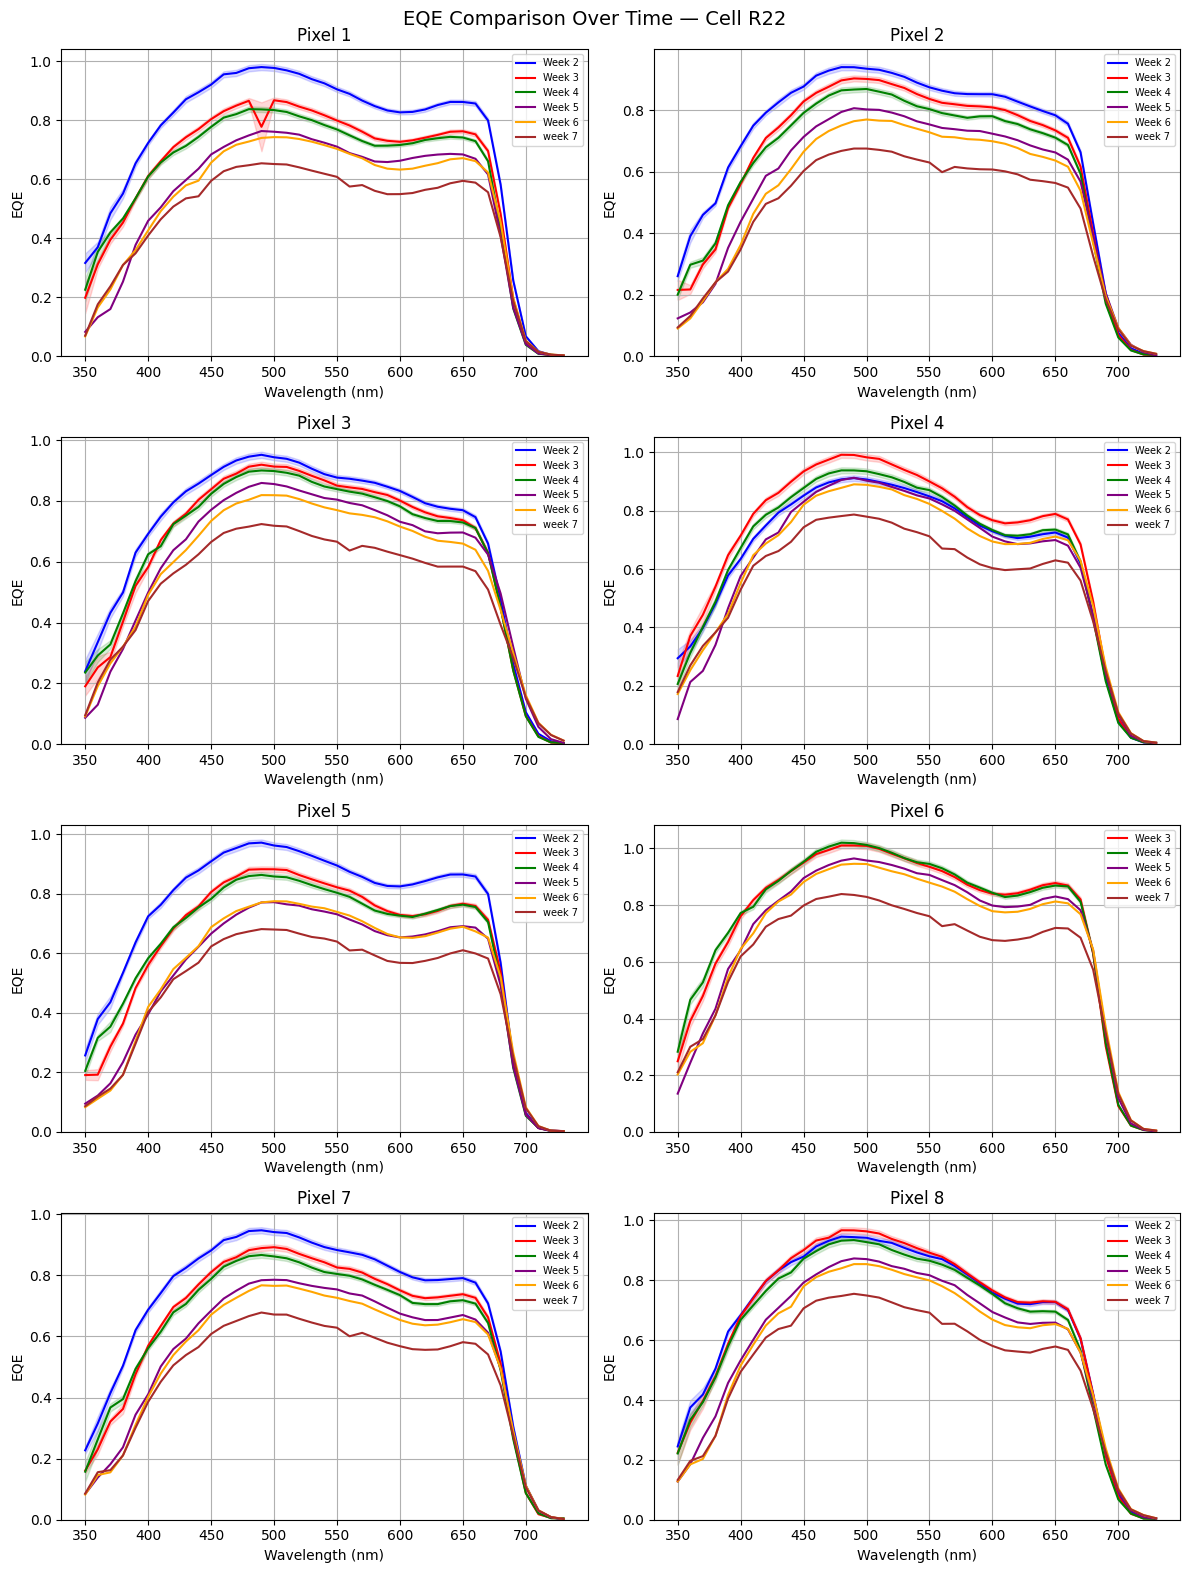

In [ ]:
# @title
# --- Multi-Week EQE Comparison with Uncertainty Bands ---

# Add your EQE CSV files here (update filenames each week)
eqe_files = {
    "Week 2": "/content/2026_02_03_eqe_cellR22.csv",
    "Week 3": "/content/2026_02_10_eqe_cellR22.csv",
    "Week 4": "/content/2026_02_17_eqe_cellR22.csv",
    "Week 5": "/content/2026_02_24_eqe_cellR22.csv",
    "Week 6": "/content/2026_03_03_eqe_cellR22.csv",
    "week 7": "/content/2026_03_10_eqe_cellR22.csv",
    # Add more weeks as needed
}

# Color cycle for different weeks
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown']

# Load all EQE files
eqe_weeks = {}
for label, fname in eqe_files.items():
    try:
        eqe_weeks[label] = pd.read_csv(fname)
        print(f"[ok] Loaded {label}: {fname}")
    except FileNotFoundError:
        print(f"[skip] {label}: {fname} not found")

if not eqe_weeks:
    print("[warn] No EQE files loaded. Check filenames above.")
else:
    fig, axes = plt.subplots(4, 2, figsize=(12, 16))
    axes_flat = axes.flatten()

    for i in range(8):
        ax = axes_flat[i]
        pix = i + 1
        col_eqe = f"eqe_pix{pix}"
        col_unc = f"eqe_unc_pix{pix}"

        for j, (label, df_eqe) in enumerate(eqe_weeks.items()):
            color = colors[j % len(colors)]
            wl = df_eqe["Wavelength (nm)"].to_numpy()

            if col_eqe in df_eqe.columns:
                eqe_vals = df_eqe[col_eqe].to_numpy()
                ax.plot(wl, eqe_vals, color=color, label=label)

                # Add uncertainty band if the column exists
                if col_unc in df_eqe.columns:
                    eqe_unc = df_eqe[col_unc].to_numpy()
                    ax.fill_between(wl,
                                    eqe_vals - eqe_unc,
                                    eqe_vals + eqe_unc,
                                    alpha=0.15, color=color)

        ax.set_title(f"Pixel {pix}")
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("EQE")
        ax.legend(fontsize=7)
        ax.set_ylim(bottom=0)
        ax.grid(True)

    plt.suptitle(f"EQE Comparison Over Time — Cell {cell_id}", fontsize=14)
    plt.tight_layout()
    plt.show()

**Question 3:** Discuss what you observe from looking at the comparison of all of your EQE curves.

The EQE is also showing a continual decrease as the weeks progress. Consistent trends are maintained throughout the wavelengths, but as time progresses the overall EQE is decreasing.

# **Author Contributions (required)**



1.   List the name of each team member and please describe briefly how each member contributed to the work in lab this week. (e.g., taking a measurement, updating the Colab notebook, etc.)

Greg - Completed some of the code, helped with data collection.
Madelyn - Helped with data collection and answering questions.
Jay - Completed some of the code, helped with data collection.

# **Use of AI (required)**



1.   How your team used AI tools: Describe the specific tasks where AI-assisted tools were involved. For example, did AI help with writing, debugging, optimizing, or refining your code? Which components of the analysis did your team use AI on?

No Ai was used for this code.

2.   When your team used AI tools: Specify at what stage(s) of your programming process you used AI. Was it during initial code development, troubleshooting, etc.?

We did not use any AI

3.   Which AI tools your team used: Identify the AI tools or platforms your team consulted (e.g., ChatGPT, GitHub Copilot, etc.).

None
